### Importação dos dados



In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [57]:


url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


# Preparação e Consolidação dos Dados
adicionar uma coluna Loja em cada DataFrame e depois uni-los em um único chamado df_completo

In [58]:
# Adiciona uma coluna 'Loja' para identificar de onde vem os dados
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# Consolida todos os DataFrames em um único
df_completo = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# Verifica o resultado
print(df_completo.head())
print(f"\nTotal de registros: {len(df_completo)}")

                 Produto Categoria do Produto    Preço      Frete  \
0     Assistente virtual          eletronicos   219.08   9.249790   
1         Mesa de jantar               moveis   256.35  11.234305   
2      Jogo de tabuleiro           brinquedos   279.51  21.262681   
3            Micro-ondas     eletrodomesticos  1009.99  54.667344   
4  Cadeira de escritório               moveis   446.99  26.964689   

  Data da Compra        Vendedor Local da compra  Avaliação da compra  \
0     16/01/2021     Pedro Gomes              SP                    4   
1     18/05/2022  Beatriz Moraes              RJ                    1   
2     15/03/2021      João Souza              DF                    1   
3     03/05/2022      João Souza              RS                    4   
4     07/11/2020   Larissa Alves              MG                    5   

  Tipo de pagamento  Quantidade de parcelas    lat    lon    Loja  
0    cartao_credito                       8 -22.19 -48.79  Loja 1  
1    carta

#1. Análise do faturamento



In [59]:
# Calcula o faturamento total (soma da coluna 'Preço')
faturamento_total = df_completo['Preço'].sum()

print(f"Faturamento Total (Todas as Lojas): R$ {faturamento_total:,.2f}")

# Calcula o faturamento por loja
faturamento_por_loja = df_completo.groupby('Loja')['Preço'].sum().sort_values(ascending=False)

print("\nFaturamento por Loja:")
# Formata a saída para melhor visualização
print(faturamento_por_loja.map('R$ {:,.2f}'.format))


Faturamento Total (Todas as Lojas): R$ 5,871,490.79

Faturamento por Loja:
Loja
Loja 1    R$ 1,534,509.12
Loja 2    R$ 1,488,459.06
Loja 3    R$ 1,464,025.03
Loja 4    R$ 1,384,497.58
Name: Preço, dtype: object


# 2. Vendas por Categoria

In [60]:
# Contar a frequência contagem de cada categoria
vendas_por_categoria = df_completo['Categoria do Produto'].value_counts().sort_values(ascending=False)

print("\n--- Vendas por Categoria Contagem ---")
print(vendas_por_categoria)

# Faturamento (R$) por categoria
faturamento_por_categoria = df_completo.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)

print("\n--- Faturamento por Categoria (R$) ---")
print(faturamento_por_categoria.map('R$ {:,.2f}'.format))


--- Vendas por Categoria Contagem ---
Categoria do Produto
moveis                   1886
eletronicos              1772
brinquedos               1290
eletrodomesticos         1149
esporte e lazer          1113
instrumentos musicais     753
livros                    742
utilidades domesticas     730
Name: count, dtype: int64

--- Faturamento por Categoria (R$) ---
Categoria do Produto
eletronicos              R$ 2,214,099.72
eletrodomesticos         R$ 1,766,337.03
moveis                   R$ 1,010,214.00
instrumentos musicais      R$ 465,029.67
esporte e lazer            R$ 190,635.39
brinquedos                  R$ 98,140.86
utilidades domesticas       R$ 76,773.38
livros                      R$ 50,260.74
Name: Preço, dtype: object


# 3. Média de Avaliação das Lojas


In [61]:
# Agrupa os dados por Loja e calcula a média da Avaliação da compra
media_avaliacao_loja = df_completo.groupby('Loja')['Avaliação da compra'].mean().sort_values(ascending=False)

print("\n--- Média de Avaliação por Loja ---")
# Formata a saída para 2 casas decimais para facilitar a leitura
print(media_avaliacao_loja.map('{:.2f}'.format))


--- Média de Avaliação por Loja ---
Loja
Loja 3    4.05
Loja 2    4.04
Loja 4    4.00
Loja 1    3.98
Name: Avaliação da compra, dtype: object


# 4. Produtos Mais e Menos Vendidos

In [62]:
# --- Produtos Mais e Menos Vendidos ---

# Contar a ocorrência de cada produto
contagem_produtos = df_completo['Produto'].value_counts()

# Exibir os 5 produtos mais vendidos
print("\n--- Produtos MAIS Vendidos (Top 5) ---")
print(contagem_produtos.head(5))

# Exibir os 5 produtos menos vendidos
print("\n--- Produtos MENOS Vendidos (Top 5) ---")
print(contagem_produtos.sort_values(ascending=True).head(5))


--- Produtos MAIS Vendidos (Top 5) ---
Produto
Cômoda                      210
Carrinho controle remoto    206
Micro-ondas                 206
Bateria                     203
Cama king                   201
Name: count, dtype: int64

--- Produtos MENOS Vendidos (Top 5) ---
Produto
Celular ABXY                   157
Headset                        158
Mochila                        163
Guitarra                       165
Ciência de dados com python    166
Name: count, dtype: int64


# 5. Frete Médio por Loja

In [63]:
# --- Frete Médio por Loja ---

# Agrupa por 'Loja' e calcula a média do 'Frete'
frete_medio_loja = df_completo.groupby('Loja')['Frete'].mean().sort_values(ascending=False)

print("\n--- Frete Médio por Loja ---")
# Formata a saída para R$ com 2 casas decimais
print(frete_medio_loja.map('R$ {:.2f}'.format))


--- Frete Médio por Loja ---
Loja
Loja 1    R$ 34.69
Loja 2    R$ 33.62
Loja 3    R$ 33.07
Loja 4    R$ 31.28
Name: Frete, dtype: object


# Gráfico 1 Faturamento por Loja ---Barras---

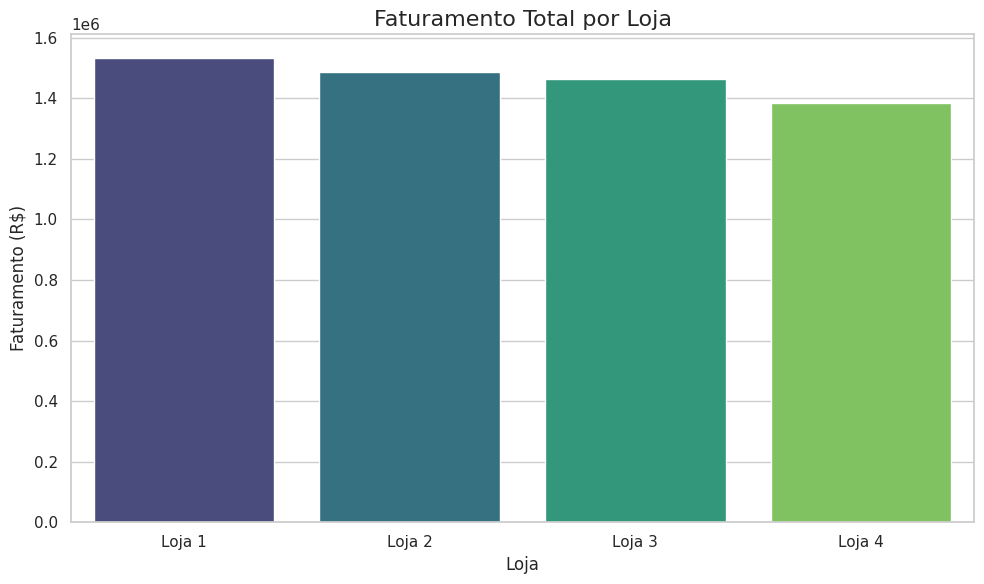

In [64]:
# --- Faturamento por Loja (Barras)

# 1. Preparar os dados
df_faturamento_loja = df_completo.groupby('Loja')['Preço'].sum().reset_index()

# 2. Configurar o gráfico
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# 3. Criar o gráfico de barras
sns.barplot(
    data=df_faturamento_loja.sort_values('Preço', ascending=False),
    x='Loja',
    y='Preço',
    hue='Loja',
    palette='viridis',
    legend=False
)

# 4. Adicionar títulos e rótulos
plt.title('Faturamento Total por Loja', fontsize=16)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)

# 5. Salvar e exibir o gráfico
plt.tight_layout()
plt.savefig('faturamento_por_loja.png')
plt.show()

# Gráfico 2 Proporção de Vendas por Categoria ---Pizza---

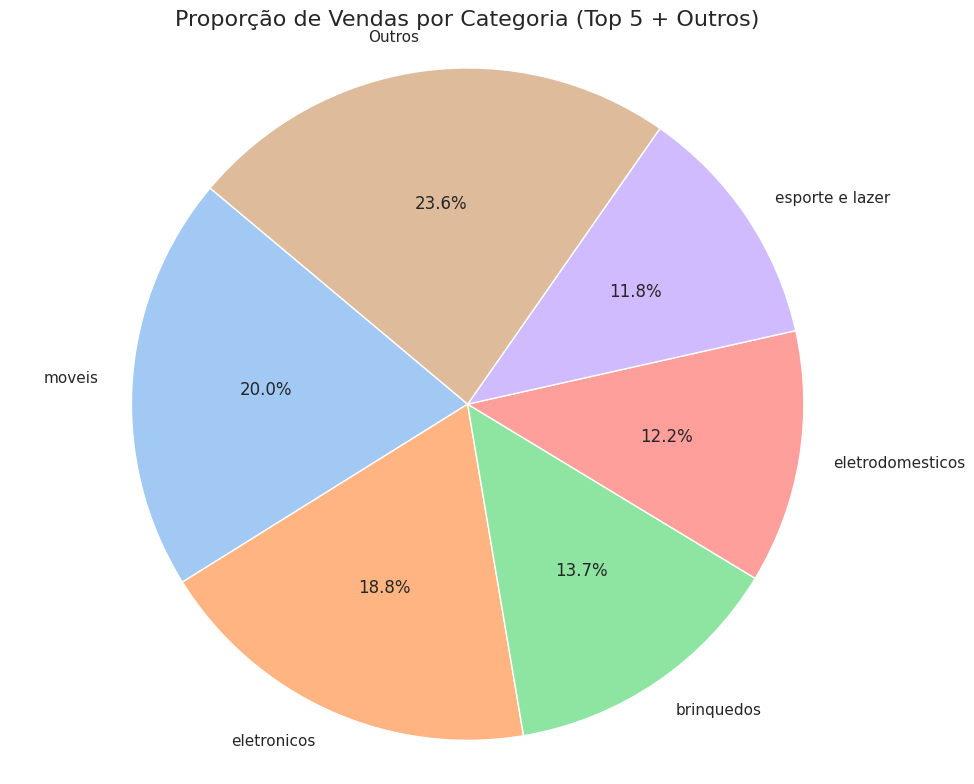

In [65]:
# Preparar os dados (Top 5 + Outros)
vendas_por_categoria = df_completo['Categoria do Produto'].value_counts()
top_5_categorias = vendas_por_categoria.head(5)

# Agrupar o restante em 'Outros'
outros_soma = vendas_por_categoria.iloc[5:].sum()
outros_series = pd.Series([outros_soma], index=['Outros'])
df_vendas_categoria = pd.concat([top_5_categorias, outros_series])

# Configurar o gráfico
plt.figure(figsize=(10, 8))

# Criar o gráfico de pizza
plt.pie(
    df_vendas_categoria,
    labels=df_vendas_categoria.index, # Rótulos de cada fatia
    autopct='%1.1f%%',                # Exibir a porcentagem
    startangle=140,                   # Ângulo inicial
    colors=sns.color_palette('pastel')# Paleta de cores suaves
)

# Adicionar título e ajustar eixo
plt.title('Proporção de Vendas por Categoria (Top 5 + Outros)', fontsize=16)
plt.axis('equal') # Garante que o gráfico seja um círculo

# Salvar e exibir o gráfico
plt.tight_layout()
plt.savefig('vendas_por_categoria_pizza.png')
plt.show()

# Gráfico 3 Faturamento ao Longo do Tempo ---Linha----

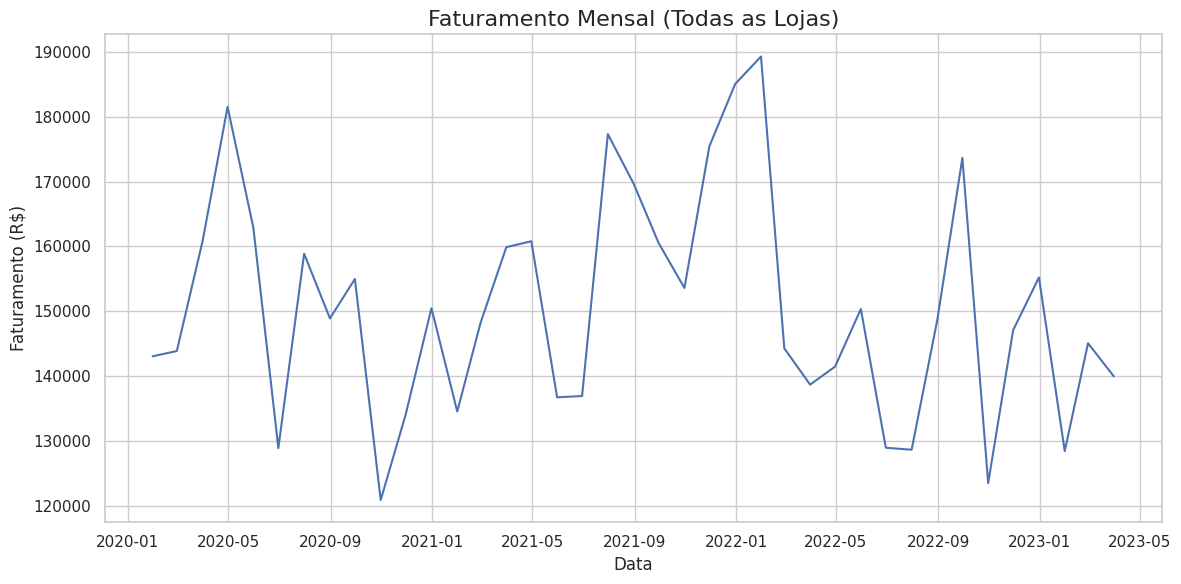

In [66]:
# Preparar os dados Análise Temporal
df_temporal = df_completo.copy()
df_temporal['Data da Compra'] = pd.to_datetime(df_temporal['Data da Compra'], format='%d/%m/%Y')

# Agrupar o faturamento por Mês usar ME em vez de M
df_temporal_mensal = df_temporal.set_index('Data da Compra').groupby(pd.Grouper(freq='ME'))['Preço'].sum().reset_index()
df_temporal_mensal.columns = ['Data', 'Faturamento']

# Configurar o gráfico
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Criar o gráfico de linha
sns.lineplot(
    data=df_temporal_mensal,
    x='Data',
    y='Faturamento'
)

# Adicionar títulos e rótulos
plt.title('Faturamento Mensal (Todas as Lojas)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)

# Salvar e exibir o gráfico
plt.tight_layout()
plt.savefig('faturamento_ao_longo_do_tempo.png')
plt.show()

#  Conclusão - Relatório de Análise Recomendação para Venda

O objetivo desta análise foi examinar o desempenho de quatro lojas (Loja 1, Loja 2, Loja 3 e Loja 4). Com base nos dados de vendas, faturamento, avaliações e logística, este relatório apresenta uma recomendação clara sobre qual unidade deve ser considerada para venda, permitindo que o Sr. João possa consolidar suas operações e focar nos ativos mais rentáveis.

# Desenvolvimento e Análise dos Dados

Para tomar uma decisão informada, foram consideradas cinco fatores principais cujos resultados são resumidos abaixo:

# Faturamento Total por Loja:
Este é o indicador de desempenho mais crítico. A análise (conforme o Gráfico de Barras) mostra que as lojas 1, 2 e 3 têm um desempenho financeiro próximo e robusto. No entanto, a Loja 4 apresenta um faturamento visivelmente inferior, sendo a que menos contribui para a receita total.

Loja 1: R$ 1.534.509,12

Loja 2: R$ 1.488.459,06

Loja 3: R$ 1.464.025,03

Loja 4: R$ 1.384.497,58

# Média de Avaliação das Lojas:
Todas as quatro lojas apresentam uma satisfação de cliente excelente e muito semelhante, com médias de avaliação quase idênticas (variando apenas de 3.98 a 4.05). Isso indica que a qualidade do serviço é consistente em toda a rede e, portanto, a avaliação não é um fator decisivo para escolher qual loja vender.

# Frete Médio por Loja:
O custo logístico (frete) foi analisado para cada loja. Embora existam pequenas variações, nenhum dos valores se destacou como um problema operacional grave ou uma vantagem decisiva que mude a recomendação principal.

# Categorias de Produtos:
A análise (conforme o Gráfico de Pizza) mostra quais categorias são mais populares em toda a rede (como eletrônicos, móveis e brinquedos). Esta informação é vital para a estratégia de estoque de todas as lojas, mas não ajuda a diferenciar o desempenho de uma loja específica em relação às outras.

# Produtos Mais e Menos Vendidos:
O ranking de produtos mais vendidos reflete o comportamento do consumidor de forma geral, sendo uma informação estratégica para toda a rede, e não um indicador para a venda de uma unidade específica.

# Conclusão e Recomendação

Com base na análise objetiva dos dados, a recomendação é que o Sr. João deve vender a Loja 4.

# O porque desta decisão

A base principal foi desempenho financeiro.

Enquanto as Lojas 1, 2 e 3 formam um bloco coeso e de alta performance, a Loja 4 é a que menos fatura, estando significativamente atrás das outras.

Embora sua avaliação de clientes seja boa (4.00), ela não é superior à das outras lojas e não compensa o faturamento mais baixo. A venda da Loja 4 é a decisão de negócios mais lógica, permitindo que o Sr. João libere capital e concentre seus esforços e investimentos nas unidades mais lucrativas (Lojas 1, 2 e 3), otimizando a rentabilidade geral da operação.

# Extra!  Análise de Desempenho Geográfico


--- Análise Geográfica Dispersão de Vendas ---


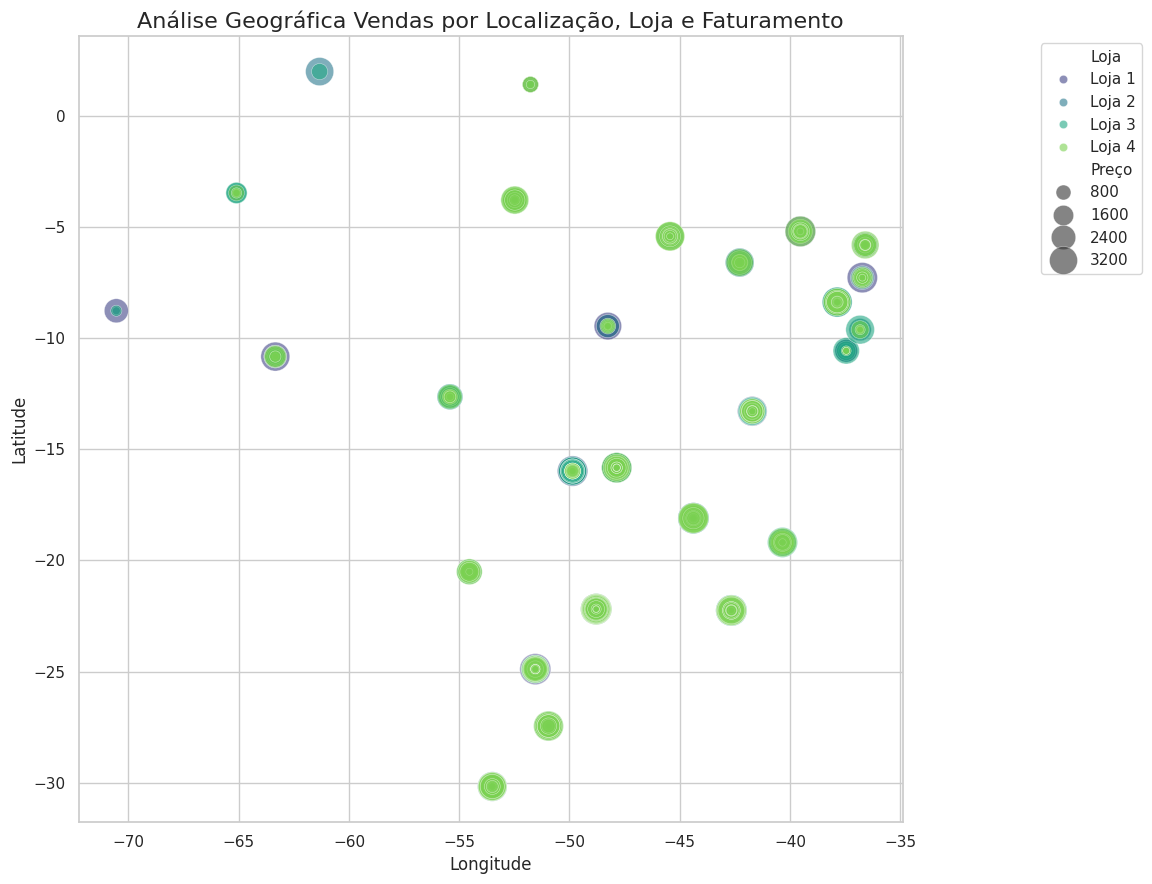

In [67]:
print("\n--- Análise Geográfica Dispersão de Vendas ---")

# Configurar o gráfico
plt.figure(figsize=(12, 9)) # Um pouco maior para ver os detalhes
sns.set(style="whitegrid")

# Criar o gráfico de dispersão scatter plot
sns.scatterplot(
    data=df_completo,
    x='lon',
    y='lat',
    hue='Loja',          # Diferencia as lojas por cor
    size='Preço',        # Diferencia o faturamento pelo tamanho
    sizes=(20, 500),     # Define a escala de tamanho dos pontos
    alpha=0.6,           # Ajuda a ver concentrações (áreas escuras)
    palette='viridis'    # Paleta de cores
)

# Adicionar títulos e rótulos
plt.title('Análise Geográfica Vendas por Localização, Loja e Faturamento', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Ajusta a legenda para não sobrepor o gráfico
plt.legend(loc='upper right', bbox_to_anchor=(1.30, 1))

# Salvar e exibir o gráfico
plt.tight_layout()
plt.savefig('analise_geografica_dispersao.png')
plt.show()